<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/fourier_series_and_transform10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Define a periodic function

Let's start by defining a simple periodic function. For demonstration, we'll use a square wave, which is a classic example for Fourier series.

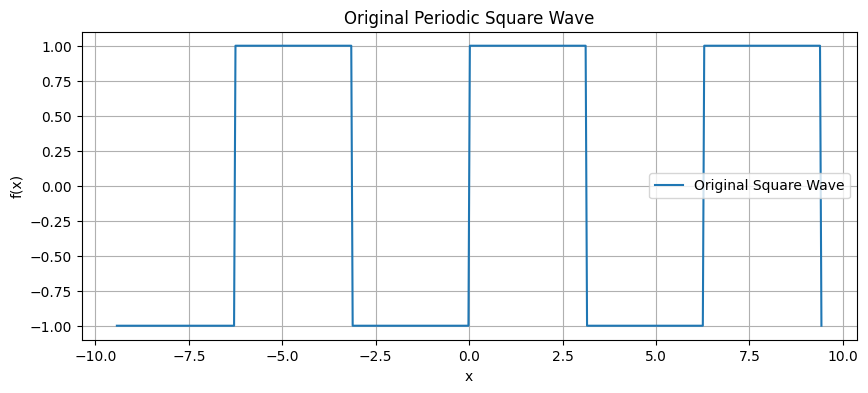

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the square wave function
# Period T = 2*pi, so L = pi (half period)
def square_wave(x, period=2*np.pi):
    x_mod = np.mod(x + period/2, period) - period/2
    return np.where(x_mod >= 0, 1.0, -1.0)

# Define the range for x
x = np.linspace(-3 * np.pi, 3 * np.pi, 500)
y_true = square_wave(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y_true, label='Original Square Wave')
plt.title('Original Periodic Square Wave')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

### 2. Calculate Fourier series coefficients

For a periodic function $f(x)$ with period $T=2L$, the Fourier series is given by:

$f(x) = a_0 + \sum_{n=1}^{\infty} \left( a_n \cos\left(\frac{n\pi x}{L}\right) + b_n \sin\left(\frac{n\pi x}{L}\right) \right)$

Where the coefficients are:

$a_0 = \frac{1}{2L} \int_{-L}^{L} f(x) \, dx$

$a_n = \frac{1}{L} \int_{-L}^{L} f(x) \cos\left(\frac{n\pi x}{L}\right) \, dx$

$b_n = \frac{1}{L} \int_{-L}^{L} f(x) \sin\left(\frac{n\pi x}{L}\right) \, dx$

For our square wave $f(x) = \begin{cases} 1 & 0 \le x < \pi \\ -1 & -\pi \le x < 0 \end{cases}$ with $L = \pi$, the coefficients are:

$a_0 = 0$ (since it's an odd function)

$a_n = 0$ (since it's an odd function and $\cos$ is even)

$b_n = \frac{2}{L} \int_{0}^{L} f(x) \sin\left(\frac{n\pi x}{L}\right) \, dx = \frac{2}{\pi} \int_{0}^{\pi} (1) \sin(nx) \, dx$

$b_n = \frac{2}{\pi} \left[ -\frac{\cos(nx)}{n} \right]_{0}^{\pi} = \frac{2}{\pi n} (1 - \cos(n\pi)) = \frac{2}{\pi n} (1 - (-1)^n)$

So, $b_n = \begin{cases} \frac{4}{\pi n} & \text{if n is odd} \\ 0 & \text{if n is even} \end{cases}$

Let's implement this to calculate the coefficients numerically.

In [ ]:
from scipy.integrate import quad

def calculate_fourier_coefficients(func, L, N_terms):
    a0 = (1/L) * quad(func, -L, L)[0] / 2 # Averages over the full period
    # Note: the definition of a0 varies. Sometimes it's (1/L) * integral, sometimes (1/(2L))*integral. Here we align with common full series forms.

    an = []
    bn = []
    for n in range(1, N_terms + 1):
        a_n = (1/L) * quad(lambda x: func(x) * np.cos(n*np.pi*x/L), -L, L)[0]
        b_n = (1/L) * quad(lambda x: func(x) * np.sin(n*np.pi*x/L), -L, L)[0]
        an.append(a_n)
        bn.append(b_n)
    return a0, an, bn

# Define the function for integration (within one period -L to L)
def square_wave_period(x):
    return np.where(x >= 0, 1.0, -1.0)

L = np.pi # Half-period
N_terms = 50 # Number of terms to include in the series

a0, an_coeffs, bn_coeffs = calculate_fourier_coefficients(square_wave_period, L, N_terms)

print(f"a0: {a0:.4f}")
print("First 5 a_n coefficients:", [f'{coeff:.4f}' for coeff in an_coeffs[:5]])
print("First 5 b_n coefficients:", [f'{coeff:.4f}' for coeff in bn_coeffs[:5]])

a0: 0.0000
First 5 a_n coefficients: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
First 5 b_n coefficients: ['1.2732', '0.0000', '0.4244', '0.0000', '0.2546']


### 3. Reconstruct the function using Fourier series

Now, let's use the calculated coefficients to reconstruct the square wave.

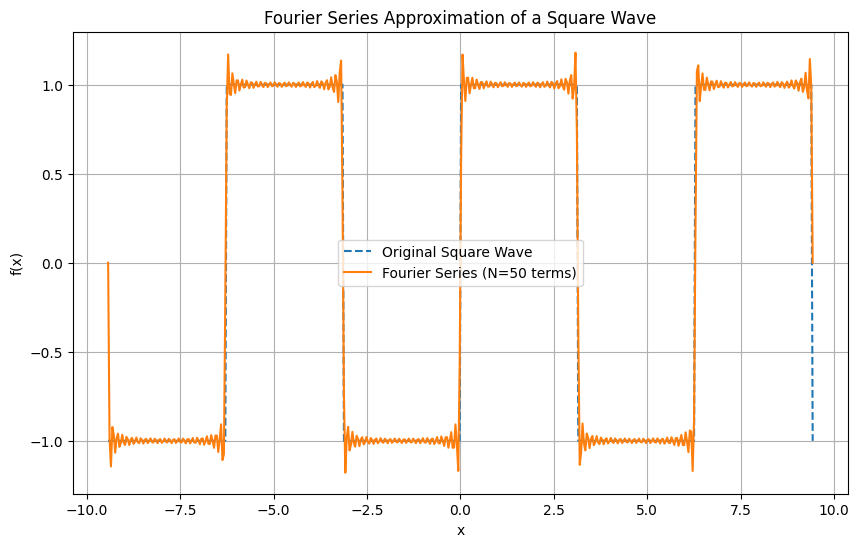

In [ ]:
def reconstruct_fourier_series(x, a0, an_coeffs, bn_coeffs, L):
    reconstructed_y = a0 * np.ones_like(x)
    for n in range(len(an_coeffs)):
        reconstructed_y += an_coeffs[n] * np.cos((n + 1) * np.pi * x / L)
        reconstructed_y += bn_coeffs[n] * np.sin((n + 1) * np.pi * x / L)
    return reconstructed_y

y_reconstructed = reconstruct_fourier_series(x, a0, an_coeffs, bn_coeffs, L)

plt.figure(figsize=(10, 6))
plt.plot(x, y_true, label='Original Square Wave', linestyle='--')
plt.plot(x, y_reconstructed, label=f'Fourier Series (N={N_terms} terms)')
plt.title('Fourier Series Approximation of a Square Wave')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

### How Fourier Series Can Solve Math Equations

This example shows how to represent a function using a Fourier series. When it comes to solving differential equations (especially linear ones with constant coefficients) that have periodic boundary conditions, the process typically involves:

1.  **Assume a Fourier series solution:** Assume the unknown solution $u(x,t)$ can be represented as a Fourier series (or a generalized Fourier series for non-periodic cases).
2.  **Substitute into the equation:** Substitute this series representation into the differential equation.
3.  **Solve for coefficients:** Use the orthogonality properties of sine and cosine functions to determine the unknown Fourier coefficients. This often turns the partial differential equation into a system of ordinary differential equations or algebraic equations for the coefficients.
4.  **Reconstruct the solution:** Once the coefficients are found, the Fourier series can be summed to reconstruct the solution to the original equation.

This method is particularly powerful for problems like heat conduction in a rod with periodic temperature at the ends, or wave propagation on a string fixed at both ends.

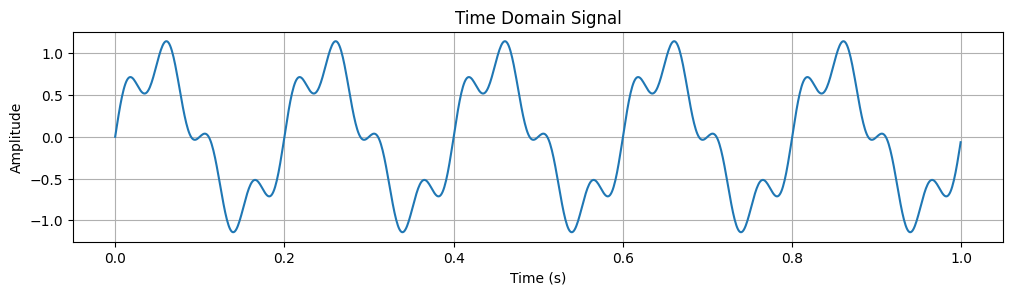

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the signal
SAMPLING_RATE = 1000  # samples per second
DURATION = 1        # seconds
FREQUENCY1 = 5      # Hz
FREQUENCY2 = 20     # Hz

# Time vector
t = np.linspace(0, DURATION, int(SAMPLING_RATE * DURATION), endpoint=False)

# Create a composite signal (sum of two sine waves)
signal = 0.9 * np.sin(2 * np.pi * FREQUENCY1 * t) + 0.3 * np.sin(2 * np.pi * FREQUENCY2 * t)

# Plot the original signal
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

Now, let's compute the Fast Fourier Transform (FFT) of this signal. The FFT converts a signal from its original domain (often time or space) to a representation in the frequency domain. We'll then plot the magnitude of the frequency components.

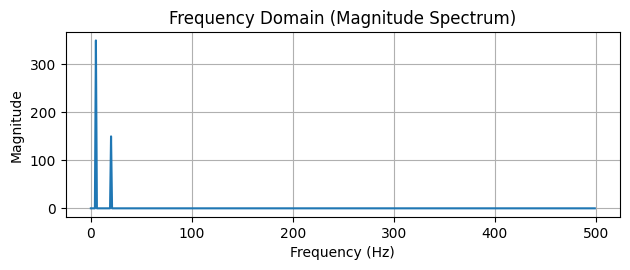

Dominant frequencies in the signal: 5.00 Hz (ignoring DC component and noise)


In [ ]:
# Compute the FFT
# np.fft.fft returns complex numbers representing frequency components
ft_signal = np.fft.fft(signal)

# Compute the frequencies corresponding to the FFT output
# The frequencies are centered around 0, going up to Nyquist frequency and then negative frequencies
frequencies = np.fft.fftfreq(len(signal), 1/SAMPLING_RATE)

# We are typically interested in the positive frequencies (magnitude spectrum)
# The FFT output is symmetric for real-valued input, so we take the first half
positive_frequencies = frequencies[:len(frequencies)//2]
magnitude_spectrum = np.abs(ft_signal)[:len(ft_signal)//2]

# Plot the magnitude spectrum
plt.subplot(2, 1, 2)
plt.plot(positive_frequencies, magnitude_spectrum)
plt.title('Frequency Domain (Magnitude Spectrum)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Dominant frequencies in the signal: {positive_frequencies[np.argmax(magnitude_spectrum)]:.2f} Hz (ignoring DC component and noise)")

In the frequency domain plot, you should see two distinct peaks corresponding to the `5 Hz` and `20 Hz` components we used to create the signal. The Fourier Transform is a powerful tool for analyzing the frequency content of signals across various fields like signal processing, image processing, and physics.